# Fraud Detection Dataset – Duplicates, Outliers, Common/Uncommon Values and DBSCAN Anomalies
**Dataset:** `Fraud_Detection_Dataset.csv` (keep it in the same folder as this notebook) · **Target:** `Fraudulent` (1 = fraud, 0 = genuine)

| Task | What is done |
|---|---|
| Task 1 | Column-wise duplicate count |
| Task 2 | Payment_Method vs Fraudulent (grouped view) and outliers in `Time_of_Transaction` (with graph) |
| Task 3 | Identify common / uncommon values (value frequencies + DBSCAN clusters) |
| Task 4 | Identify anomalies (cluster = -1) for a different feature set |
| Task 5 | Graphs for the anomalies |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Fraud_Detection_Dataset.csv")
print(df.shape)
df.head()

(51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [3]:
df.columns.tolist()
list(df)

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Time_of_Transaction',
 'Device_Used',
 'Location',
 'Previous_Fraudulent_Transactions',
 'Account_Age',
 'Number_of_Transactions_Last_24H',
 'Payment_Method',
 'Fraudulent']

In [4]:
df=df.dropna()

> **Note:** `dropna()` removes every row that has a missing value in any column (about 5 % of values are missing in each of five columns), so the working data shrinks from 51,000 to **39,583 rows**. The checks below are done on this cleaned data.

In [5]:
missing_percent = df.isnull().mean()*100

print(missing_percent)

Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64


In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 688


## Task 1: Column-wise duplicate count
For each column: how many values are repeats of a value already seen (`Series.duplicated()`), and which value repeats the most.

In [7]:
dup_table = pd.DataFrame({
    "Total rows": len(df),
    "Unique values": df.nunique(),
    "Duplicate count": df.apply(lambda s: s.duplicated().sum()),
})
dup_table["Duplicate %"] = (dup_table["Duplicate count"] / dup_table["Total rows"] * 100).round(2)
dup_table["Most repeated value"] = df.apply(lambda s: s.value_counts().index[0])
dup_table["Its count"] = df.apply(lambda s: s.value_counts().iloc[0])
dup_table.sort_values("Duplicate count", ascending=False)

,Total rows,Unique values,Duplicate count,Duplicate %,Most repeated value,Its count
Fraudulent,39583,2,39581,99.99,0,37651
Device_Used,39583,4,39579,99.99,Desktop,12835
Transaction_Type,39583,5,39578,99.99,Bank Transfer,8012
Payment_Method,39583,5,39578,99.99,UPI,9758
Previous_Fraudulent_Transactions,39583,5,39578,99.99,2,8083
Location,39583,8,39575,99.98,Boston,5045
Number_of_Transactions_Last_24H,39583,14,39569,99.96,5,2934
Time_of_Transaction,39583,24,39559,99.94,18.0,1737
Account_Age,39583,119,39464,99.70,45,379
User_ID,39583,4000,35583,89.89,3134,23


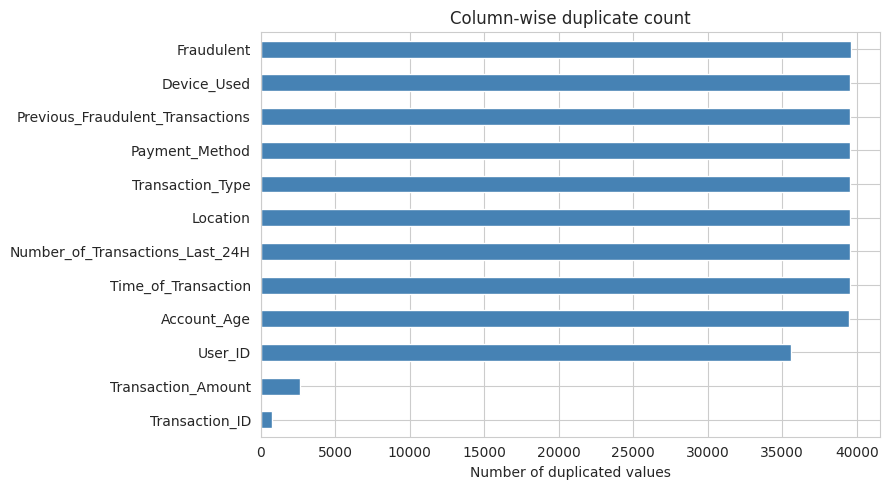

Columns with NO duplicate values: []
Fully identical rows (all columns): 688


In [8]:
ax = dup_table["Duplicate count"].sort_values().plot(kind="barh", figsize=(9,5), color="steelblue")
ax.set_title("Column-wise duplicate count")
ax.set_xlabel("Number of duplicated values")
plt.tight_layout()
plt.show()

print("Columns with NO duplicate values:", list(dup_table.index[dup_table["Duplicate count"] == 0]))
print("Fully identical rows (all columns):", df.duplicated().sum())

`Duplicate count` = `Total rows − Unique values`. Low-cardinality columns (e.g. `Fraudulent`, `Device_Used`) naturally have almost every value duplicated, which is expected. The columns worth attention are the identifiers: `Transaction_ID` should be unique, so any duplicate there points to repeated records (the full-row duplicate count above confirms this).

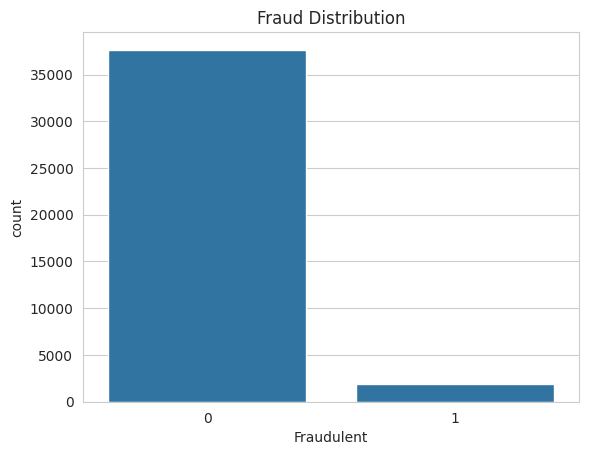

In [9]:
sns.countplot(x="Fraudulent", data=df)

plt.title("Fraud Distribution")

plt.show()

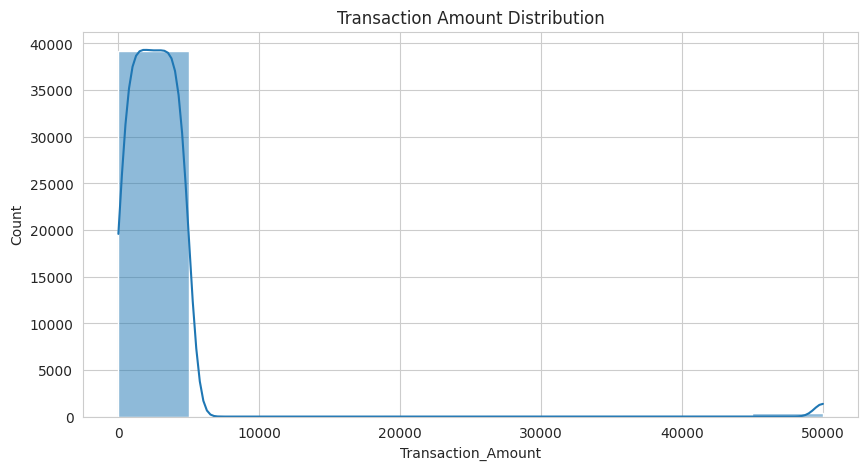

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Transaction_Amount"],
    bins=10,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

## Task 2a: Payment_Method vs Fraudulent
Transactions are grouped by `Payment_Method`, and fraud counts and fraud rate are compared across the groups.

In [11]:
ct = pd.crosstab(df["Payment_Method"], df["Fraudulent"])
ct.columns = ["Genuine (0)", "Fraud (1)"]
ct["Total"] = ct.sum(axis=1)
ct["Fraud rate %"] = (ct["Fraud (1)"] / ct["Total"] * 100).round(2)
ct

,Genuine (0),Fraud (1),Total,Fraud rate %
Payment_Method,,,,
Credit Card,9009,460,9469,4.86
Debit Card,9167,456,9623,4.74
Invalid Method,1174,56,1230,4.55
Net Banking,9029,474,9503,4.99
UPI,9272,486,9758,4.98


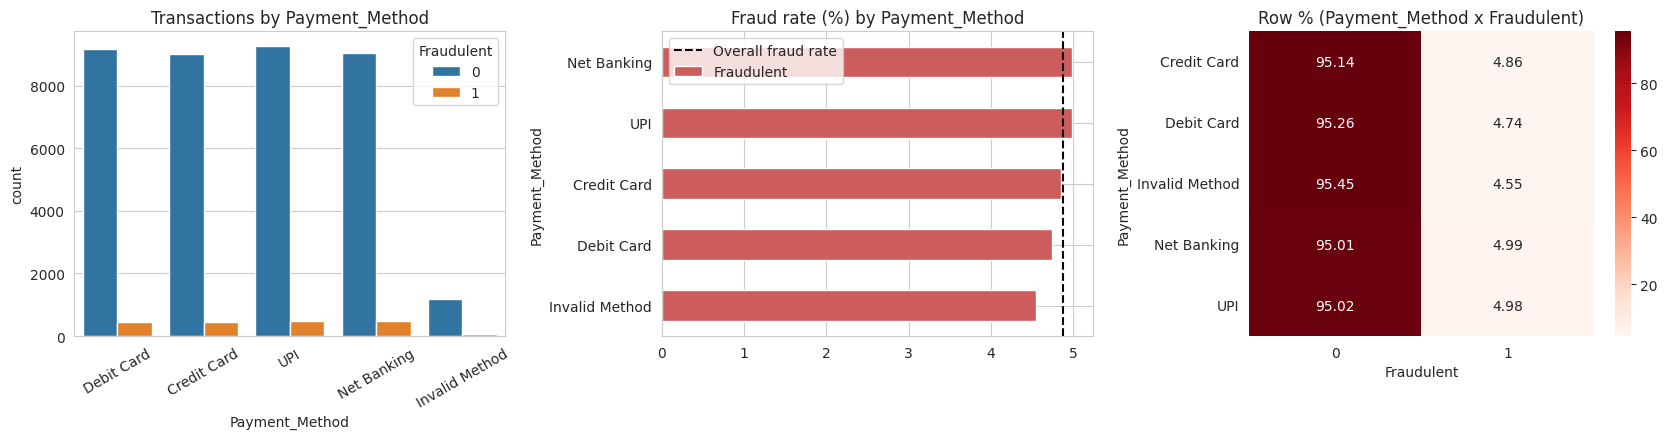

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(data=df, x="Payment_Method", hue="Fraudulent", ax=axes[0])
axes[0].set_title("Transactions by Payment_Method")
axes[0].tick_params(axis="x", rotation=30)

rate = df.groupby("Payment_Method")["Fraudulent"].mean().mul(100).sort_values()
rate.plot(kind="barh", ax=axes[1], color="indianred")
axes[1].axvline(df["Fraudulent"].mean() * 100, color="k", ls="--", label="Overall fraud rate")
axes[1].set_title("Fraud rate (%) by Payment_Method"); axes[1].legend()

row_pct = pd.crosstab(df["Payment_Method"], df["Fraudulent"], normalize="index") * 100
sns.heatmap(row_pct, annot=True, fmt=".2f", cmap="Reds", ax=axes[2])
axes[2].set_title("Row % (Payment_Method x Fraudulent)")

plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import chi2_contingency
chi2, p, dof, _ = chi2_contingency(pd.crosstab(df["Payment_Method"], df["Fraudulent"]))
print(f"Chi-square = {chi2:.3f}, dof = {dof}, p-value = {p:.4f}")
print("Fraud depends on Payment_Method" if p < 0.05 else "No significant relationship between Payment_Method and Fraudulent (p >= 0.05)")

Chi-square = 1.158, dof = 4, p-value = 0.8849
No significant relationship between Payment_Method and Fraudulent (p >= 0.05)


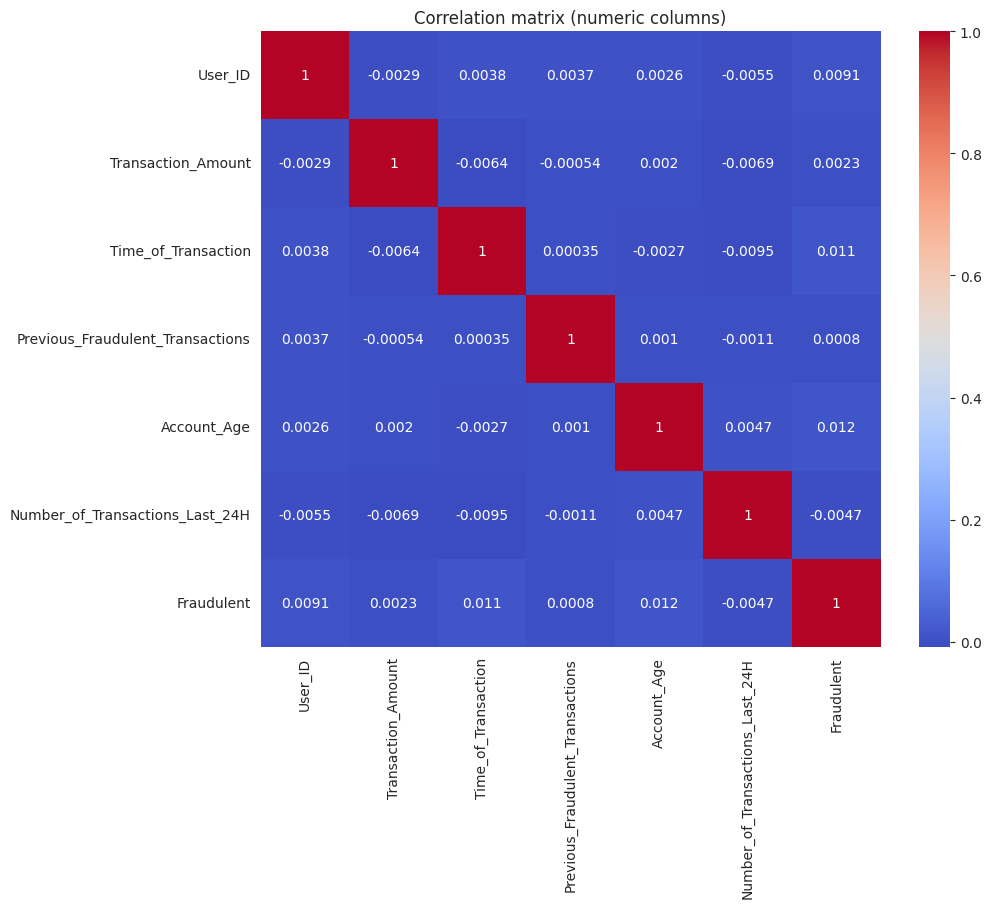

In [14]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(

numeric.corr(),

annot=True,

cmap="coolwarm"

)

plt.title("Correlation matrix (numeric columns)")
plt.show()

# Outlier

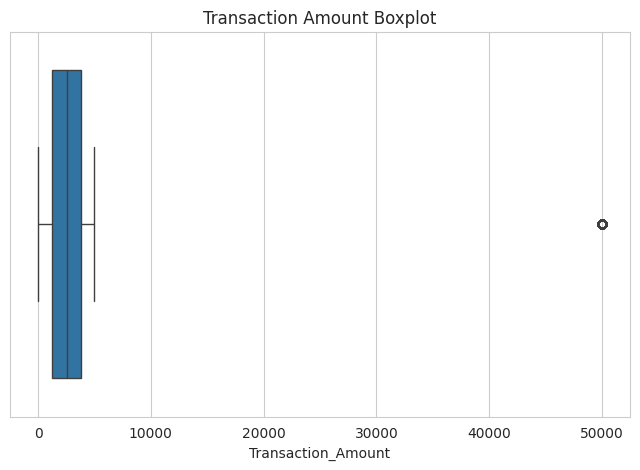

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Transaction_Amount"]
)

plt.title("Transaction Amount Boxplot")
plt.show()

In [16]:
Q1 = df["Transaction_Amount"].quantile(0.25)

Q3 = df["Transaction_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR


outliers = df[
    (df["Transaction_Amount"] < lower) |
    (df["Transaction_Amount"] > upper)
]

#Lower_outlier= df[df["Transaction_Amount"] < lower]

#Lower_outlier.head()

#upper_outlier= df[df["Transaction_Amount"] < upper]

#upper_outlier.head()
#upper_outlier.shape
#Lower_outlier.shape
print(outliers.shape)
#outliers.head()

(416, 12)


`Transaction_Amount` has **416 outliers, all on the high side** (the printed `(416, 12)` is rows × columns); none fall below the lower fence. Every one of them has exactly the same amount, **49,997.80**, which is about ten times the largest "normal" amount (4,999.78). A repeated, round-ceiling value like this looks like a data-entry/system placeholder rather than genuine spending, so it should be checked at source before modelling.

## Task 2b: Outliers in Time_of_Transaction
IQR rule (values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are outliers), plus a boxplot and histogram.

In [17]:
col = "Time_of_Transaction"
Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
IQR = Q3 - Q1
lower_t, upper_t = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

time_outliers = df[(df[col] < lower_t) | (df[col] > upper_t)]
print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Lower fence = {lower_t}, Upper fence = {upper_t}")
print(f"Observed range: {df[col].min()} to {df[col].max()}")
print("Number of outliers in Time_of_Transaction:", len(time_outliers))

Q1 = 5.0, Q3 = 17.0, IQR = 12.0
Lower fence = -13.0, Upper fence = 35.0
Observed range: 0.0 to 23.0
Number of outliers in Time_of_Transaction: 0


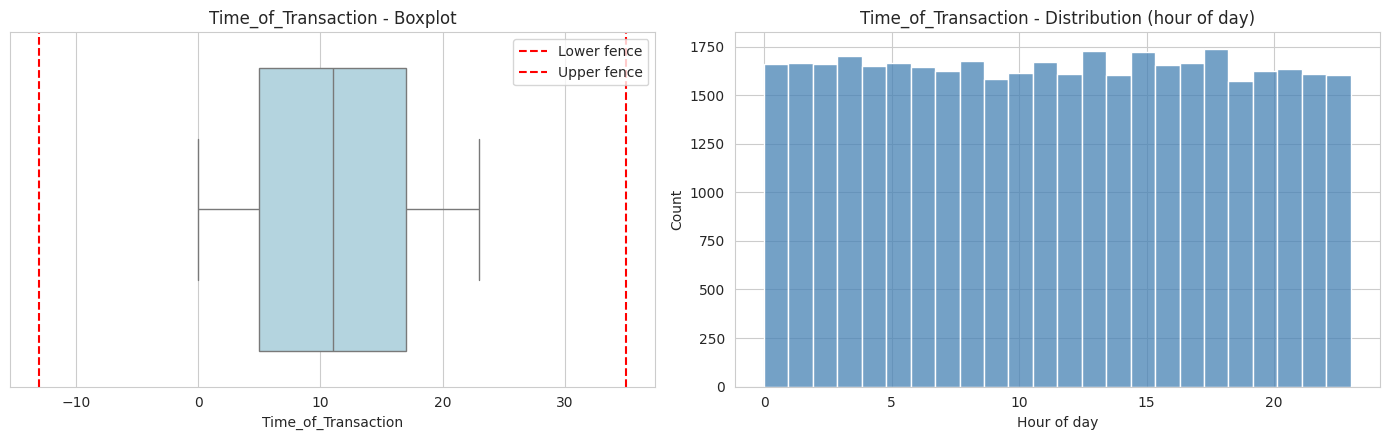

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(x=df[col], ax=axes[0], color="lightblue")
axes[0].axvline(lower_t, color="red", ls="--", label="Lower fence")
axes[0].axvline(upper_t, color="red", ls="--", label="Upper fence")
axes[0].set_title("Time_of_Transaction - Boxplot"); axes[0].legend()

sns.histplot(df[col], bins=24, kde=False, ax=axes[1], color="steelblue")
axes[1].set_title("Time_of_Transaction - Distribution (hour of day)")
axes[1].set_xlabel("Hour of day")

plt.tight_layout()
plt.show()

`Time_of_Transaction` is an hour of the day (0–23), so every value lies inside the IQR fences and **there are no outliers** – the histogram is almost flat, i.e. transactions are spread evenly over the day.

## Task 3: Identify common / uncommon values
**(a) By value frequency.** For columns with few distinct values, a value is called **uncommon** when its share is less than half of an equal share (`1 / number of distinct values`), otherwise **common**.

In [19]:
low_card = [c for c in df.columns if df[c].nunique() <= 25]
rows = []
for c in low_card:
    vc = df[c].value_counts()
    equal_share = 1 / len(vc)
    for v, n in vc.items():
        share = n / len(df)
        rows.append([c, v, n, round(share * 100, 2), "Uncommon" if share < 0.5 * equal_share else "Common"])

freq = pd.DataFrame(rows, columns=["Column", "Value", "Count", "Share %", "Type"])
print("Uncommon values found:")
freq[freq["Type"] == "Uncommon"]

Uncommon values found:


,Column,Value,Count,Share %,Type
32,Device_Used,Unknown Device,1237,3.13,Uncommon
64,Payment_Method,Invalid Method,1230,3.11,Uncommon
66,Fraudulent,1,1932,4.88,Uncommon


In [20]:
# Full list, column by column
freq.set_index(["Column", "Value"])

Count  Share %      Type
Column           Value                                    
Transaction_Type Bank Transfer     8012    20.24    Common
                 Bill Payment      7963    20.12    Common
                 ATM Withdrawal    7890    19.93    Common
                 POS Payment       7871    19.88    Common
                 Online Purchase   7847    19.82    Common
...                                 ...      ...       ...
Payment_Method   Net Banking       9503    24.01    Common
                 Credit Card       9469    23.92    Common
                 Invalid Method    1230     3.11  Uncommon
Fraudulent       0.0              37651    95.12    Common
                 1.0               1932     4.88  Uncommon

[67 rows x 3 columns]

In [21]:
# High-cardinality columns: 3 most common and 3 least common values
for c in ["Transaction_Amount", "Account_Age"]:
    vc = df[c].value_counts()
    print(f"\n{c}  ({df[c].nunique()} distinct values)")
    print("  Most common :", {k: int(v) for k, v in vc.head(3).items()})
    print("  Least common:", {k: int(v) for k, v in vc[vc == vc.min()].head(3).items()}, f"(each appears {vc.min()} time(s))")


Transaction_Amount  (36916 distinct values)
  Most common : {49997.8: 416, 3562.91: 4, 1747.31: 4}
  Least common: {1292.76: 1, 1554.58: 1, 100.1: 1} (each appears 1 time(s))

Account_Age  (119 distinct values)
  Most common : {45: 379, 106: 375, 29: 372}
  Least common: {12: 294} (each appears 294 time(s))


**(b) By DBSCAN clustering.** DBSCAN groups dense (common) records into clusters `0, 1, 2 ...`; records that do not fit any dense group are labelled **-1** (uncommon / anomaly). Features are standardised first so no single column dominates.

In [22]:
features = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]


In [23]:
from sklearn.preprocessing import StandardScaler

X = df[features]
#X=X.dropna()
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [24]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=15
)

labels = dbscan.fit_predict(X_scaled)

In [25]:
df["Cluster"] = labels
#df.head()
df["Cluster"].value_counts()

Cluster
 0    39167
 1      408
-1        8
Name: count, dtype: int64

In [26]:
cluster_summary = df["Cluster"].value_counts().rename_axis("Cluster").reset_index(name="Rows")
cluster_summary["Share %"] = (cluster_summary["Rows"] / len(df) * 100).round(2)
cluster_summary["Type"] = np.where(cluster_summary["Cluster"] == -1, "Uncommon (noise)", "Common (clustered)")
display(cluster_summary)

# What makes each cluster different? (mean of each feature)
df.groupby("Cluster")[features].mean().round(2)

,Cluster,Rows,Share %,Type
0,0,39167,98.95,Common (clustered)
1,1,408,1.03,Common (clustered)
2,-1,8,0.02,Uncommon (noise)


,Transaction_Amount,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H
Cluster,,,,
-1,49997.80,1.38,18.88,5.00
0,2496.05,2.00,59.93,7.50
1,49997.80,1.99,62.36,7.35


## Task 4: Anomalies (cluster = -1)
**(a) Feature set 1** – `Transaction_Amount`, `Previous_Fraudulent_Transactions`, `Account_Age`, `Number_of_Transactions_Last_24H` (the clustering above).

In [27]:
suspicious = df[df["Cluster"] == -1]

print(suspicious.head())

      Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
317             T318     4681             49997.8     Bill Payment   
8146           T8147     1640             49997.8     Bill Payment   
15441         T15442     4030             49997.8    Bank Transfer   
19824         T19825     2206             49997.8  Online Purchase   
22058         T22059     3612             49997.8    Bank Transfer   

       Time_of_Transaction Device_Used     Location  \
317                    0.0      Mobile      Houston   
8146                  17.0      Tablet  Los Angeles   
15441                 20.0     Desktop      Seattle   
19824                 14.0      Mobile        Miami   
22058                 20.0      Tablet     New York   

       Previous_Fraudulent_Transactions  Account_Age  \
317                                   4            4   
8146                                  4            7   
15441                                 0            5   
19824                   

In [28]:
print("Anomalies with feature set 1:", len(suspicious), "rows")
suspicious[features].describe().round(2)

Anomalies with feature set 1: 8 rows


,Transaction_Amount,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H
count,8.0,8.00,8.00,8.00
mean,49997.8,1.38,18.88,5.00
std,0.0,1.69,40.53,5.73
min,49997.8,0.00,2.00,1.00
25%,49997.8,0.00,2.75,1.00
50%,49997.8,1.00,4.50,2.00
75%,49997.8,1.75,7.50,7.25
max,49997.8,4.00,119.00,14.00


**(b) A different feature set** – `Transaction_Amount`, `Time_of_Transaction`, `Account_Age`, `Number_of_Transactions_Last_24H` (swapping `Previous_Fraudulent_Transactions` for `Time_of_Transaction`). `eps = 0.6`, `min_samples = 15`.

In [29]:
features2 = [
    "Transaction_Amount",
    "Time_of_Transaction",
    "Account_Age",
    "Number_of_Transactions_Last_24H",
]

X2 = StandardScaler().fit_transform(df[features2])

dbscan2 = DBSCAN(eps=0.6, min_samples=15)
df["Cluster_2"] = dbscan2.fit_predict(X2)

print("Cluster sizes (feature set 2):")
print(df["Cluster_2"].value_counts().sort_index())

Cluster sizes (feature set 2):
Cluster_2
-1      300
 0    39167
 1       29
 2       56
 3       15
 4       16
Name: count, dtype: int64


In [30]:
suspicious2 = df[df["Cluster_2"] == -1]
print("Anomalies with feature set 2:", len(suspicious2), "rows",
      f"({len(suspicious2)/len(df)*100:.2f}% of data)")
suspicious2.head(10)

Anomalies with feature set 2: 300 rows (0.76% of data)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Cluster,Cluster_2
245,T246,2306,49997.8,Bill Payment,1.0,Desktop,New York,3,78,9,UPI,0,1,-1
298,T299,2153,49997.8,Online Purchase,18.0,Tablet,San Francisco,2,85,2,Net Banking,0,1,-1
317,T318,4681,49997.8,Bill Payment,0.0,Mobile,Houston,4,4,14,Credit Card,0,-1,-1
551,T552,2982,49997.8,Bill Payment,17.0,Tablet,Chicago,3,37,7,Invalid Method,1,1,-1
561,T562,3617,49997.8,Bill Payment,14.0,Tablet,Chicago,3,10,3,Credit Card,0,1,-1
773,T774,3914,49997.8,Bill Payment,21.0,Desktop,San Francisco,3,6,12,UPI,0,1,-1
790,T791,4304,49997.8,POS Payment,19.0,Mobile,San Francisco,1,103,5,Invalid Method,0,1,-1
1282,T1283,2305,49997.8,Bill Payment,1.0,Mobile,Seattle,3,72,12,UPI,0,1,-1
1553,T1554,4051,49997.8,Online Purchase,0.0,Mobile,San Francisco,0,55,11,UPI,0,1,-1
1574,T1575,4797,49997.8,Online Purchase,3.0,Desktop,Houston,2,57,8,Net Banking,0,1,-1


In [31]:
# Compare anomalies with the rest of the data
compare = pd.DataFrame({
    "Anomalies (-1)": suspicious2[features2].mean(),
    "Normal (clustered)": df[df["Cluster_2"] != -1][features2].mean(),
}).round(2)
display(compare)

print("Fraud rate - anomalies :", round(suspicious2["Fraudulent"].mean() * 100, 2), "%")
print("Fraud rate - normal    :", round(df[df["Cluster_2"] != -1]["Fraudulent"].mean() * 100, 2), "%")
print("Fraud rate - overall   :", round(df["Fraudulent"].mean() * 100, 2), "%")

,Anomalies (-1),Normal (clustered)
Transaction_Amount,49997.80,2636.32
Time_of_Transaction,12.81,11.45
Account_Age,55.66,59.98
Number_of_Transactions_Last_24H,7.59,7.49


Fraud rate - anomalies : 6.33 %
Fraud rate - normal    : 4.87 %
Fraud rate - overall   : 4.88 %


In [32]:
# Overlap between the two feature sets
both = df[(df["Cluster"] == -1) & (df["Cluster_2"] == -1)]
print("Flagged by set 1 only:", ((df["Cluster"] == -1) & (df["Cluster_2"] != -1)).sum())
print("Flagged by set 2 only:", ((df["Cluster"] != -1) & (df["Cluster_2"] == -1)).sum())
print("Flagged by both      :", len(both))

Flagged by set 1 only: 0
Flagged by set 2 only: 292
Flagged by both      : 8


### Task 5: Cluster Graph (any two attributes)

In [33]:
x_attr = "Transaction_Amount"   
y_attr = "Previous_Fraudulent_Transactions"          


**Graph 1 – feature set 1:** normal clusters (sampled for speed) and anomalies in red.

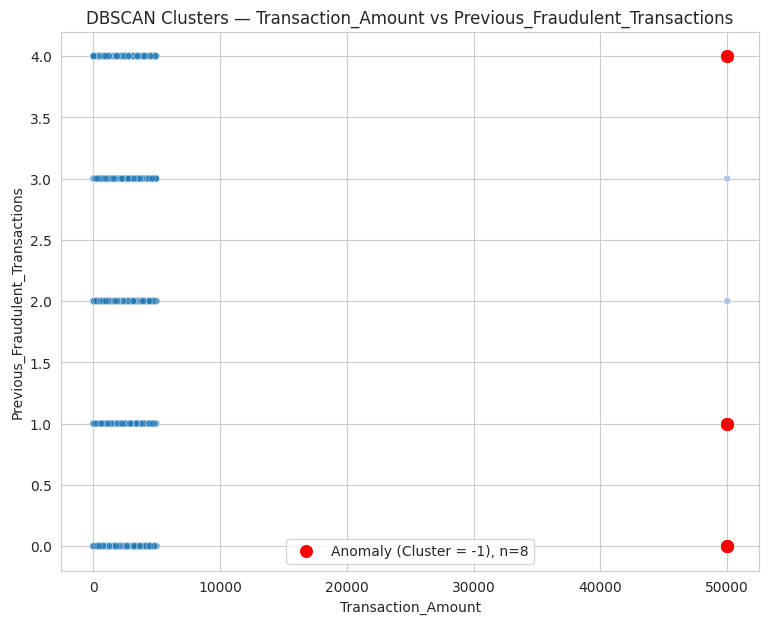

In [34]:
non_noise = df[df["Cluster"] != -1]
noise = df[df["Cluster"] == -1]

sample_size = min(3000, len(non_noise))
plot_sample = non_noise.sample(n=sample_size, random_state=42)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=plot_sample,
    x=x_attr, y=y_attr,
    hue="Cluster",
    palette="tab20",
    alpha=0.6, s=25,
    legend=False
)

plt.scatter(
    noise[x_attr], noise[y_attr],
    c="red", marker="o", s=70,
    label=f"Anomaly (Cluster = -1), n={len(noise)}"
)

plt.xlabel(x_attr)
plt.ylabel(y_attr)
plt.title(f"DBSCAN Clusters — {x_attr} vs {y_attr}")
plt.legend()
plt.show()


**Graph 2 – feature set 2:** `Account_Age` vs `Transaction_Amount`, anomalies (cluster = -1) in red.

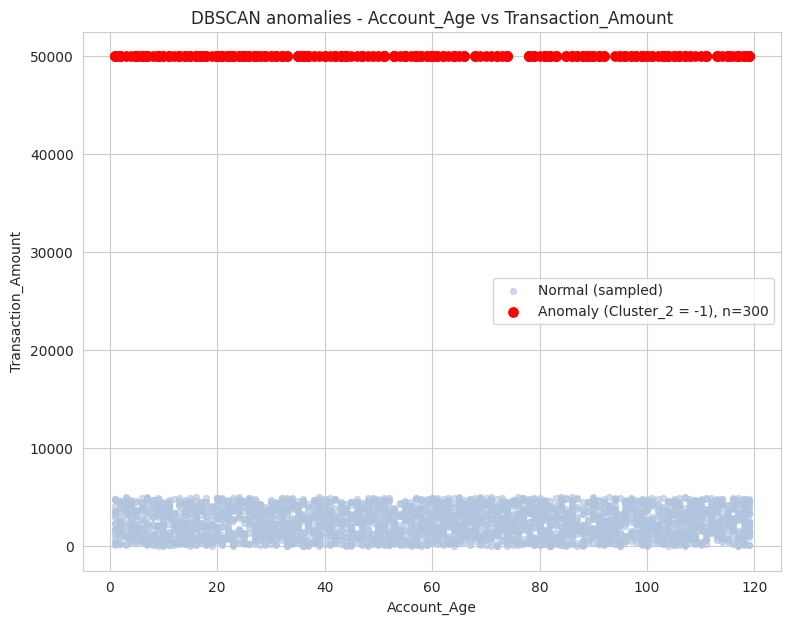

In [35]:
non_noise2 = df[df["Cluster_2"] != -1]
plot_sample2 = non_noise2.sample(n=min(3000, len(non_noise2)), random_state=42)

plt.figure(figsize=(9, 7))
plt.scatter(plot_sample2["Account_Age"], plot_sample2["Transaction_Amount"],
            c="lightsteelblue", s=18, alpha=0.6, label="Normal (sampled)")
plt.scatter(suspicious2["Account_Age"], suspicious2["Transaction_Amount"],
            c="red", s=45, label=f"Anomaly (Cluster_2 = -1), n={len(suspicious2)}")
plt.xlabel("Account_Age"); plt.ylabel("Transaction_Amount")
plt.title("DBSCAN anomalies - Account_Age vs Transaction_Amount")
plt.legend()
plt.show()

**Graph 3 – how do anomalies differ from normal records?**

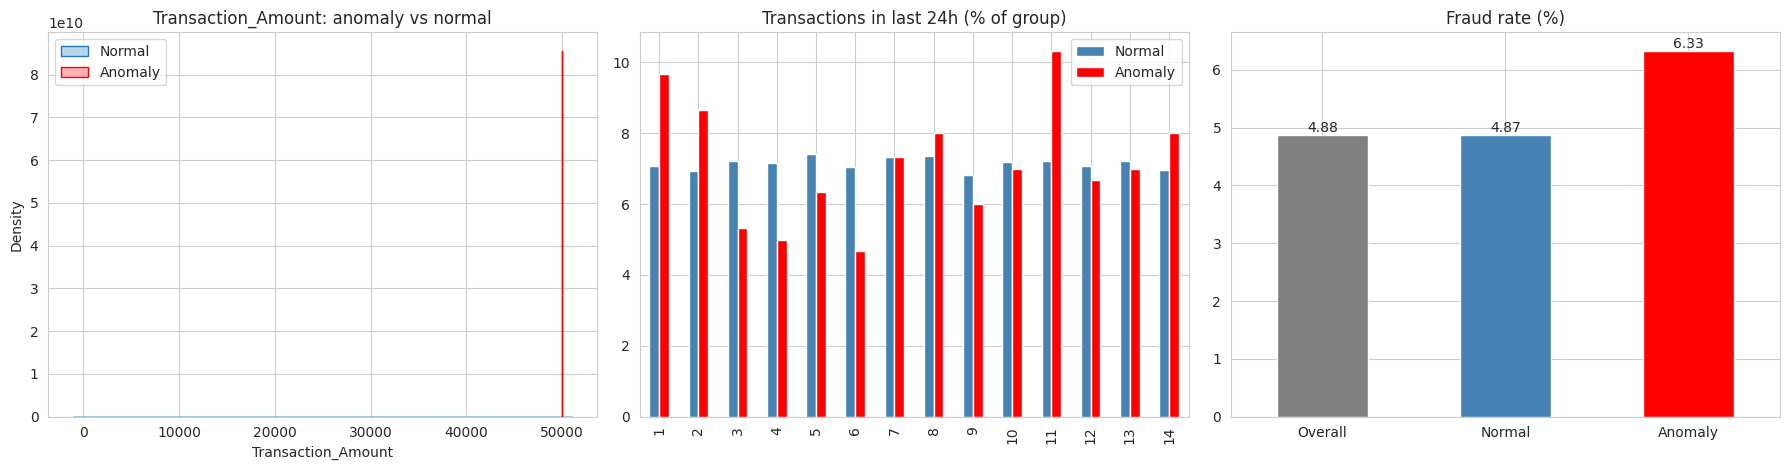

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# (a) feature distributions: anomalies vs normal
sns.kdeplot(non_noise2["Transaction_Amount"], ax=axes[0], label="Normal", fill=True, alpha=0.3, common_norm=False)
sns.kdeplot(suspicious2["Transaction_Amount"], ax=axes[0], label="Anomaly", fill=True, alpha=0.3, color="red", common_norm=False)
axes[0].set_title("Transaction_Amount: anomaly vs normal"); axes[0].legend()

# (b) number of transactions in last 24h
order = sorted(df["Number_of_Transactions_Last_24H"].unique())
share = pd.DataFrame({
    "Normal": non_noise2["Number_of_Transactions_Last_24H"].value_counts(normalize=True),
    "Anomaly": suspicious2["Number_of_Transactions_Last_24H"].value_counts(normalize=True),
}).reindex(order).fillna(0) * 100
share.plot(kind="bar", ax=axes[1], color=["steelblue", "red"])
axes[1].set_title("Transactions in last 24h (% of group)"); axes[1].set_xlabel("")

# (c) fraud rate
fr = pd.Series({
    "Overall": df["Fraudulent"].mean() * 100,
    "Normal": non_noise2["Fraudulent"].mean() * 100,
    "Anomaly": suspicious2["Fraudulent"].mean() * 100,
})
fr.plot(kind="bar", ax=axes[2], color=["gray", "steelblue", "red"])
axes[2].set_title("Fraud rate (%)"); axes[2].tick_params(axis="x", rotation=0)
for i, v in enumerate(fr):
    axes[2].text(i, v + 0.05, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

### Conclusions
**Task 1 – duplicates:** apart from the identifier columns, every column is heavily repeated, which is normal for low-cardinality fields. `Transaction_ID` has 787 repeated IDs and 688 rows are fully identical, so the data contains duplicate records that should be removed before modelling.

**Task 2 – Payment_Method vs Fraudulent:** fraud rates are almost the same across all payment methods (chi-square p = 0.88), so payment method does not explain fraud. `Time_of_Transaction` is an hour of the day (0–23) and has **no outliers**. `Transaction_Amount` has 416 outliers, all exactly 49,997.80.

**Task 3 – common / uncommon values:** by frequency, the uncommon values are `Unknown Device` (3.1 %), `Invalid Method` (3.1 %) and `Fraudulent = 1` (4.9 %). DBSCAN on feature set 1 puts 98.95 % of rows in a common cluster 0, 1.03 % in cluster 1 (the 49,997.80 amounts) and only 8 rows in noise.

**Task 4 – anomalies (-1):** feature set 1 flags just 8 rows, all with the 49,997.80 amount. With the different feature set (Time_of_Transaction instead of Previous_Fraudulent_Transactions) DBSCAN flags 300 rows (0.76 %). All 8 rows from set 1 are also flagged by set 2, so the second set is broader.

**Task 5 – graphs:** the cluster scatter plots and comparison charts show that the anomalies are driven mainly by the extreme amount value, not by account age or transaction counts. Their fraud rate is 6.33 % against 4.87 % for normal rows; with only 300 anomalies (about 19 frauds) this gap is **not statistically significant**, so anomaly status alone is not a reliable fraud indicator in this data.